# Assignment M6: Logistic Regression
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   OPIM 5604 Module 6 Logistic Regression.ipynb
*   KhramtchenkoGeorgeOPIM5604AssignmentM5.ipynb
*   Google Gemini


# Environment Setup

In [664]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm

In [665]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Load the Data

To practice logistic regression, we need a dataset that has a categorical target.  The **Telco Customer Churn** dataset can be used to predict if a customer will churn or not churn. Each row represents a telco customer and the target variable is called the **Churn Label**.

**Prompt 1:** Read in the dataset and determine how many rows and columns it has.

In [666]:
df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 6/Assignment M6/Telco_customer_churn.csv')
# Obtain the number of rows and columns this data has
print(df.shape)

(7043, 18)


**Answer:** This dataset has **7,043** rows and **18** columns.

Print the head elements of each column row for initial data visualization.

In [667]:
# Preview
print(df.head())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

**Prompt 2:** The target variable for this dataset is the churn column.  Check the datatypes of the predictor variables.  Make dummy variables if needed.

List all columns with their corresponding data types.

In [668]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Contract           7043 non-null   object 
 13  Paperless Billing  7043 non-null   object 
 14  Electronic Check   7043 non-null   object 
 15  Monthly Charges    7043 non-null   float64
 16  Churn Label        7043 

We have a mix of categorical and continuous predictors. I'll change the target variable to 1s and 0s.

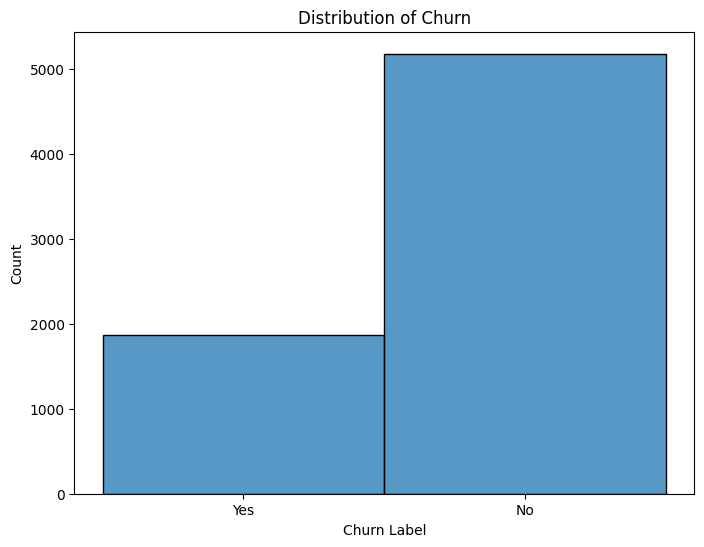


Counts of Churn Label
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [669]:
# Show a histogram of 'Churn Label' counts
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Churn Label', bins=2) # bins=2 for two categories (0 and 1)
plt.title('Distribution of Churn')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.xticks([0, 1]) # Set x-axis ticks at 0 and 1
plt.show()

# Display counts
churn_counts = df['Churn Label'].value_counts()
print("\nCounts of Churn Label")
print(churn_counts)

Convert the 'Churn Label' column to numerical values using map, required for logistic regression.

In [670]:
# Convert 'Churn Label' to numerical (Yes=1, No=0) using map
df['Churn Value'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# Display the first few rows and unique values to see the changes in the target variable
print(df.head())
print("\nUnique values after conversion:")
print(df['Churn Label'].unique())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

Verify the mapping changes took effect.

In [671]:
# Look at counts of 0 and 1 values for Churn Label to check our work
churn_counts = df['Churn Label'].value_counts()
print("Counts of Churn Labels (0s and 1s):")
print(churn_counts)

Counts of Churn Labels (0s and 1s):
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [672]:
# Display the first few rows and unique values to see the changes in the target variable
print(df.head())
print("\nUnique values after conversion:")
print(df['Churn Label'].unique())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

Drop CustomerID because it has too many categories and is irrelevant to this assignment.

In [673]:
# Drop the 'CustomerID' column
df = df.drop('CustomerID', axis=1)

Show a bar plot of the contract types to see if it can be used for dummy variables.

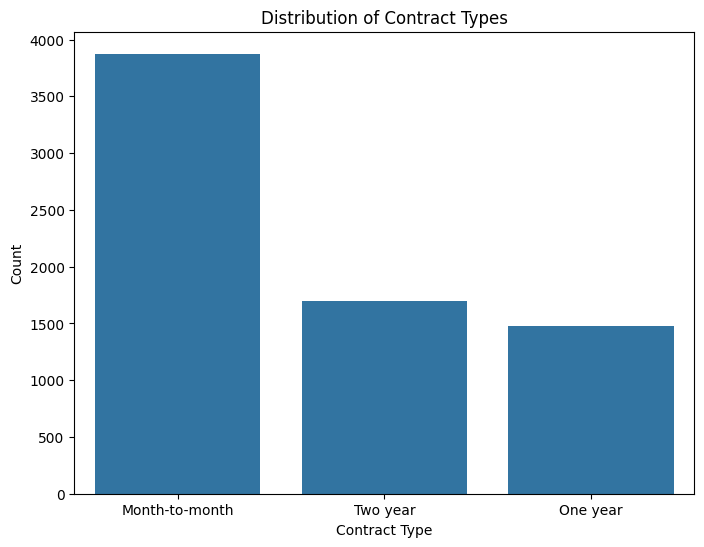


Counts of Contract Levels:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Percentages of Contract Levels:
Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


In [674]:
# Show a histogram/bar plot of 'Contract' with counts
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract')
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Display counts and percentages
contract_counts = df['Contract'].value_counts()
contract_percentages = df['Contract'].value_counts(normalize=True) * 100

print("\nCounts of Contract Levels:")
print(contract_counts)

print("\nPercentages of Contract Levels:")
print(contract_percentages)

**Prompt 3:** Partition the data into a 60/20/20 split.

*Step 1:* Create dummy variable(s) before building the logistic regression model.

In [675]:
# Create dummy variables for 'Contract'
df = pd.get_dummies(df, columns=['Contract'], drop_first=True)

# Display the first few rows to see the changes
print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Multiple Lines  \
0    Male             No      No         No              2             No   
1  Female             No      No        Yes              2             No   
2  Female             No      No        Yes              8            Yes   
3  Female             No     Yes        Yes             28            Yes   
4    Male             No      No        Yes             49            Yes   

  Internet Service Online Security Online Backup Device Protection  \
0              DSL             Yes           Yes                No   
1      Fiber optic              No            No                No   
2      Fiber optic              No            No               Yes   
3      Fiber optic              No            No               Yes   
4      Fiber optic              No           Yes               Yes   

  Tech Support Paperless Billing Electronic Check  Monthly Charges  \
0           No               Yes              

*Step 2:* Partition the data to prepare for modeling, utilizing Churn Label as the target variable with the rest of the columns being used as our initial predictor variables. A 60/20/20 split will be utilized.

In [676]:
from sklearn.model_selection import train_test_split

# Define the target variable
target = 'Churn Label'
# Define features by dropping the target variable and 'Churn Value'
features = df.drop([target, 'Churn Value'], axis=1)
target_variable = df[target]

# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (4225, 16) (4225,)
Validation set shape: (1409, 16) (1409,)
Test set shape: (1409, 16) (1409,)


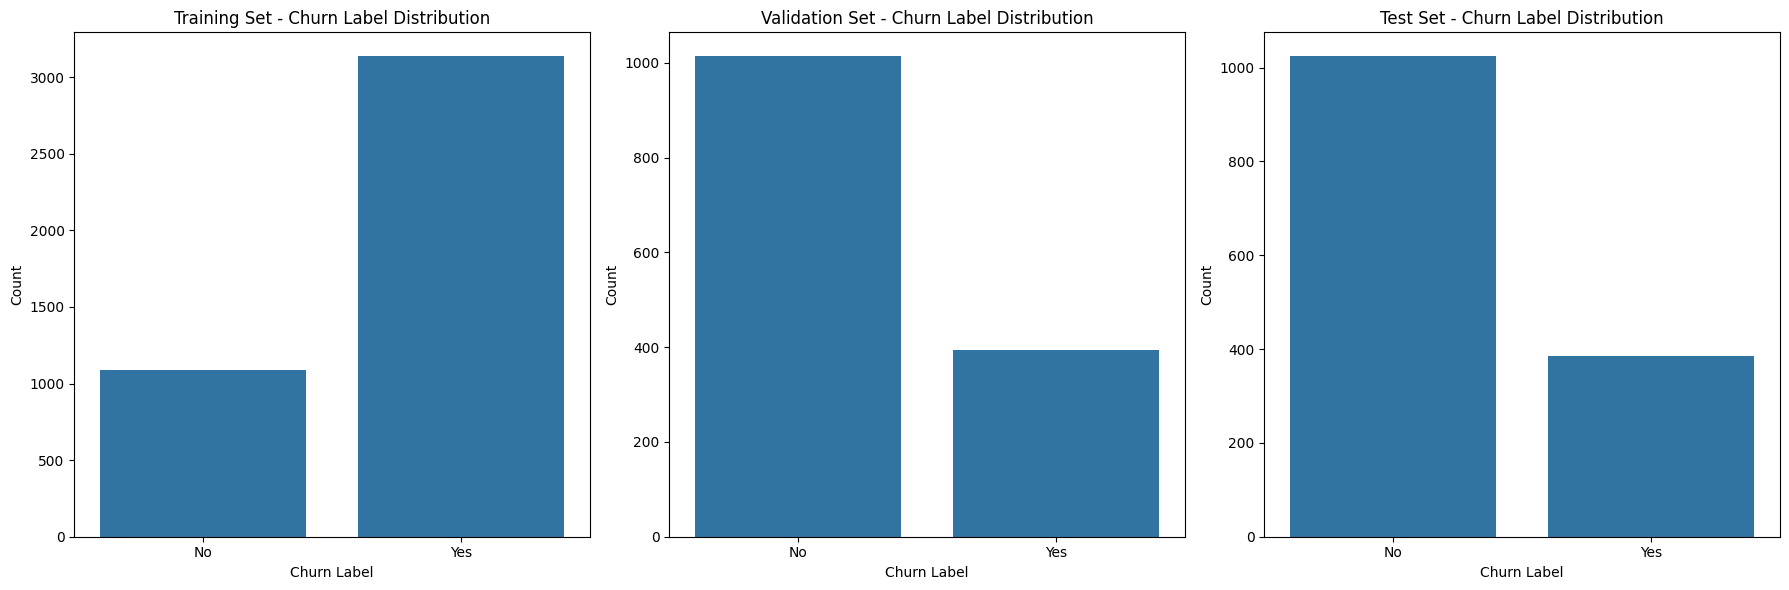

Training set Churn Label counts and percentages:
Churn Label
No     3136
Yes    1089
Name: count, dtype: int64
Churn Label
No     74.22
Yes    25.78
Name: proportion, dtype: float64

Validation set Churn Label counts and percentages:
Churn Label
No     1014
Yes     395
Name: count, dtype: int64
Churn Label
No     71.97
Yes    28.03
Name: proportion, dtype: float64

Test set Churn Label counts and percentages:
Churn Label
No     1024
Yes     385
Name: count, dtype: int64
Churn Label
No     72.68
Yes    27.32
Name: proportion, dtype: float64


In [677]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the features and target for plotting
train_data = X_train.copy()
train_data['Churn Label'] = y_train

val_data = X_val.copy()
val_data['Churn Label'] = y_val

test_data = X_test.copy()
test_data['Churn Label'] = y_test

# Plot the distribution of 'Churn Label' in each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x='Churn Label', ax=axs[0])
axs[0].set_title('Training Set - Churn Label Distribution')
axs[0].set_xlabel('Churn Label')
axs[0].set_ylabel('Count')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No', 'Yes'])

sns.countplot(data=val_data, x='Churn Label', ax=axs[1])
axs[1].set_title('Validation Set - Churn Label Distribution')
axs[1].set_xlabel('Churn Label')
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No', 'Yes'])

sns.countplot(data=test_data, x='Churn Label', ax=axs[2])
axs[2].set_title('Test Set - Churn Label Distribution')
axs[2].set_xlabel('Churn Label')
axs[2].set_ylabel('Count')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print counts and percentages for each partition
print("Training set Churn Label counts and percentages:")
train_counts = train_data['Churn Label'].value_counts()
train_percentages = train_data['Churn Label'].value_counts(normalize=True) * 100
print(train_counts)
print(train_percentages.round(2)) # Round percentages to 2 decimal places

print("\nValidation set Churn Label counts and percentages:")
val_counts = val_data['Churn Label'].value_counts()
val_percentages = val_data['Churn Label'].value_counts(normalize=True) * 100
print(val_counts)
print(val_percentages.round(2)) # Round percentages to 2 decimal places

print("\nTest set Churn Label counts and percentages:")
test_counts = test_data['Churn Label'].value_counts()
test_percentages = test_data['Churn Label'].value_counts(normalize=True) * 100
print(test_counts)
print(test_percentages.round(2)) # Round percentages to 2 decimal places

# Logistic Regression

A logistic regression model will need to be built since the target variable is a categorical one.

##Train the Model

In [678]:
# Identify remaining categorical columns
# Source: Gemini AI
categorical_cols = X_train.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", categorical_cols)

# Apply one-hot encoding to categorical columns into a binary format #
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

print("\nShape of X_train after one-hot encoding:", X_train.shape)
print("Shape of X_val after one-hot encoding:", X_val.shape)
print("Shape of X_test after one-hot encoding:", X_test.shape)

Categorical columns to encode: Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Paperless Billing',
       'Electronic Check'],
      dtype='object')

Shape of X_train after one-hot encoding: (4225, 18)
Shape of X_val after one-hot encoding: (1409, 18)
Shape of X_test after one-hot encoding: (1409, 18)


Apply one-hot encoding to categorical columns into a binary format. Source: **Generated by Gemini AI.**

In [679]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Identify remaining categorical columns (assuming they are still in X_train, X_val, X_test)
# This step might be redundant if one-hot encoding was applied earlier, but including
# it here as a safeguard in case previous encoding was skipped or incomplete.
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns # Include bool in case get_dummies created bool columns

# Apply one-hot encoding to categorical columns into a binary format
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - this is crucial after one-hot encoding to ensure all sets
# have the same columns before fitting/predicting. Reindexing with training columns
# and filling missing values with 0 is a common approach.
train_cols = X_train_encoded.columns
X_val_encoded = X_val_encoded.reindex(columns=train_cols, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=train_cols, fill_value=0)

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence
logistic_model.fit(X_train_encoded, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Then we make predictions using the formula that was fitted on the training data.

In [680]:
# Make predictions (classes) on the training, validation, and test sets
y_train_pred = logistic_model.predict(X_train_encoded)
y_val_pred = logistic_model.predict(X_val_encoded)
y_test_pred = logistic_model.predict(X_test_encoded)

# Get predicted probabilities for the training, validation, and test sets
y_train_proba = logistic_model.predict_proba(X_train_encoded)[:, 1] # Probability of the positive class (1)
y_val_proba = logistic_model.predict_proba(X_val_encoded)[:, 1]
y_test_proba = logistic_model.predict_proba(X_test_encoded)[:, 1]

print("Predictions (classes and probabilities) made successfully on training, validation, and test sets.")

Predictions (classes and probabilities) made successfully on training, validation, and test sets.


Show actuals, probabilities, and predictions for the first 10 rows of the test set in a DataFrame.

In [681]:
import pandas as pd

results_df = pd.DataFrame({
    'Actual': y_test.head(10).tolist(),
    'Predicted Probability (Churn Label=1)': y_test_proba[:10].tolist(),
    'Predicted Class': y_test_pred[:10].tolist()
})

print("Actuals, Probabilities, and Predicted Churn Label (First 10 rows of Test Set):")
display(results_df)

Actuals, Probabilities, and Predicted Churn Label (First 10 rows of Test Set):


,Actual,Predicted Probability (Churn Label=1),Predicted Class
0,No,0.015555,No
1,No,0.561325,Yes
2,Yes,0.744787,Yes
3,No,0.013395,No
4,No,0.087263,No
5,Yes,0.091276,No
6,No,0.023382,No
7,Yes,0.784604,Yes
8,No,0.306350,No
9,No,0.509714,Yes


Since only two of the rows above have a probability near 0.5, let's check again and be more specific.

In [682]:
# Filter the test set to show rows where predicted probability is between 0.45 and 0.55
uncertain_predictions_indices = (y_test_proba >= 0.45) & (y_test_proba <= 0.55)

# Get the corresponding actual values, predicted probabilities, and predicted classes
uncertain_actual = y_test[uncertain_predictions_indices]
uncertain_proba = y_test_proba[uncertain_predictions_indices]
uncertain_pred = y_test_pred[uncertain_predictions_indices]

# Create a DataFrame to display these results
uncertain_results_df = pd.DataFrame({
    'Actual': uncertain_actual,
    'Predicted Probability (Churn Label=1)': uncertain_proba,
    'Predicted Class': uncertain_pred
})

# Display the first 10 rows from this filtered DataFrame
print("Test Set Rows with Predicted Probability between 0.45 and 0.55 (First 10):")
display(uncertain_results_df.head(10))

# Also show the number of such cases
print(f"\nNumber of cases with predicted probability between 0.45 and 0.55 in the test set: {len(uncertain_results_df)}")

Test Set Rows with Predicted Probability between 0.45 and 0.55 (First 10):


,Actual,Predicted Probability (Churn Label=1),Predicted Class
2447,No,0.509714,Yes
6542,No,0.469792,No
4039,No,0.470360,No
252,Yes,0.476958,No
1608,Yes,0.531451,Yes
4288,No,0.459127,No
810,Yes,0.492658,No
3393,No,0.452403,No
432,Yes,0.501124,Yes
62,Yes,0.488182,No



Number of cases with predicted probability between 0.45 and 0.55 in the test set: 97


Learn more  about the predcitros by assessing the sign of the coefficients.  Positive coefficients make people more likely to churn, while negative coefficients make people less likely to churn.  

In [683]:
# Show the coefficients of the logistic regression model, including the intercept
feature_names = X_train.columns
coefficients = logistic_model.coef_[0]
intercept = logistic_model.intercept_[0]

# Create a DataFrame for coefficients and feature names
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Add the intercept to the DataFrame
intercept_df = pd.DataFrame({'Feature': ['Intercept'], 'Coefficient': [intercept]})
coef_df = pd.concat([intercept_df, coef_df], ignore_index=True)

print("\nCoefficients (including Intercept) with Feature Names:")
print(coef_df)


Coefficients (including Intercept) with Feature Names:
                            Feature  Coefficient
0                         Intercept    -1.729326
1                     Tenure Months    -0.037278
2                   Monthly Charges     0.024949
3                 Contract_One year    -0.589715
4                 Contract_Two year    -1.249059
5                       Gender_Male    -0.002391
6                Senior Citizen_Yes    -0.006113
7                       Partner_Yes     0.239020
8                    Dependents_Yes    -1.486899
9   Multiple Lines_No phone service     0.848717
10               Multiple Lines_Yes     0.298607
11     Internet Service_Fiber optic     0.108582
12              Internet Service_No    -0.168019
13              Online Security_Yes    -0.531126
14                Online Backup_Yes    -0.188576
15            Device Protection_Yes    -0.080340
16                 Tech Support_Yes    -0.415363
17            Paperless Billing_Yes     0.404871
18           

Calculate and print the regression formula.

In [684]:
# Show the regression formula
# The formula for logistic regression is: log(p / (1 - p)) = b0 + b1*x1 + b2*x2 + ... + bn*xn
# Rearranging for p: p = 1 / (1 + exp(-(b0 + b1*x1 + b2*x2 + ... + bn*xn)))

intercept = logistic_model.intercept_[0]

linear_combination = f"{intercept:.4f}"
for i, feature in enumerate(feature_names):
    linear_combination += f" + {coefficients[i]:.4f}*{feature}"

formula = f"p = 1 / (1 + exp(-({linear_combination})))"

print("Logistic Regression Formula (with probability on the left):")
print(formula)

Logistic Regression Formula (with probability on the left):
p = 1 / (1 + exp(-(-1.7293 + -0.0373*Tenure Months + 0.0249*Monthly Charges + -0.5897*Contract_One year + -1.2491*Contract_Two year + -0.0024*Gender_Male + -0.0061*Senior Citizen_Yes + 0.2390*Partner_Yes + -1.4869*Dependents_Yes + 0.8487*Multiple Lines_No phone service + 0.2986*Multiple Lines_Yes + 0.1086*Internet Service_Fiber optic + -0.1680*Internet Service_No + -0.5311*Online Security_Yes + -0.1886*Online Backup_Yes + -0.0803*Device Protection_Yes + -0.4154*Tech Support_Yes + 0.4049*Paperless Billing_Yes + 0.3816*Electronic Check_Yes)))


##Model Performance

View the confusion matrices to begin assessing model performance for training, validation, and test partitions.

Confusion Matrix - Training Set:
[[2823  313]
 [ 496  593]]

Confusion Matrix - Validation Set:
[[917  97]
 [149 246]]

Confusion Matrix - Test Set:
[[914 110]
 [168 217]]


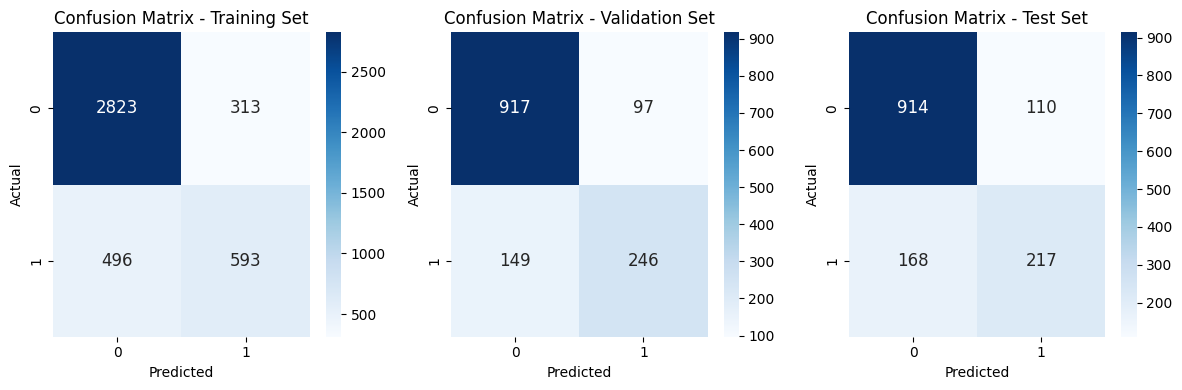

In [685]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix for the training set
cm_train = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix - Training Set:")
print(cm_train)

# Calculate confusion matrix for the validation set
cm_val = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix - Validation Set:")
print(cm_val)

# Calculate confusion matrix for the test set
cm_test = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix - Test Set:")
print(cm_test)

# Optional: Visualize Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 12})
axes[0].set_title('Confusion Matrix - Training Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 12})
axes[1].set_title('Confusion Matrix - Validation Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[2], annot_kws={"size": 12})
axes[2].set_title('Confusion Matrix - Test Set')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Prompt 5, Step 1:** Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.

View the classification report which shows the important model performance metrics.

In [686]:
from sklearn.metrics import classification_report

# Show classification report for the training set
print("Classification Report - Training Set:")
print(classification_report(y_train, y_train_pred))

# Show classification report for the validation set
print("\nClassification Report - Validation Set:")
print(classification_report(y_val, y_val_pred))

# Show classification report for the test set
print("\nClassification Report - Test Set:")
print(classification_report(y_test, y_test_pred))

Classification Report - Training Set:
              precision    recall  f1-score   support

          No       0.85      0.90      0.87      3136
         Yes       0.65      0.54      0.59      1089

    accuracy                           0.81      4225
   macro avg       0.75      0.72      0.73      4225
weighted avg       0.80      0.81      0.80      4225


Classification Report - Validation Set:
              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1014
         Yes       0.72      0.62      0.67       395

    accuracy                           0.83      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.82      0.83      0.82      1409


Classification Report - Test Set:
              precision    recall  f1-score   support

          No       0.84      0.89      0.87      1024
         Yes       0.66      0.56      0.61       385

    accuracy                           0.80      1409
   macro avg  

**Prompt 5, Step 2:** Check model performance by AUC.

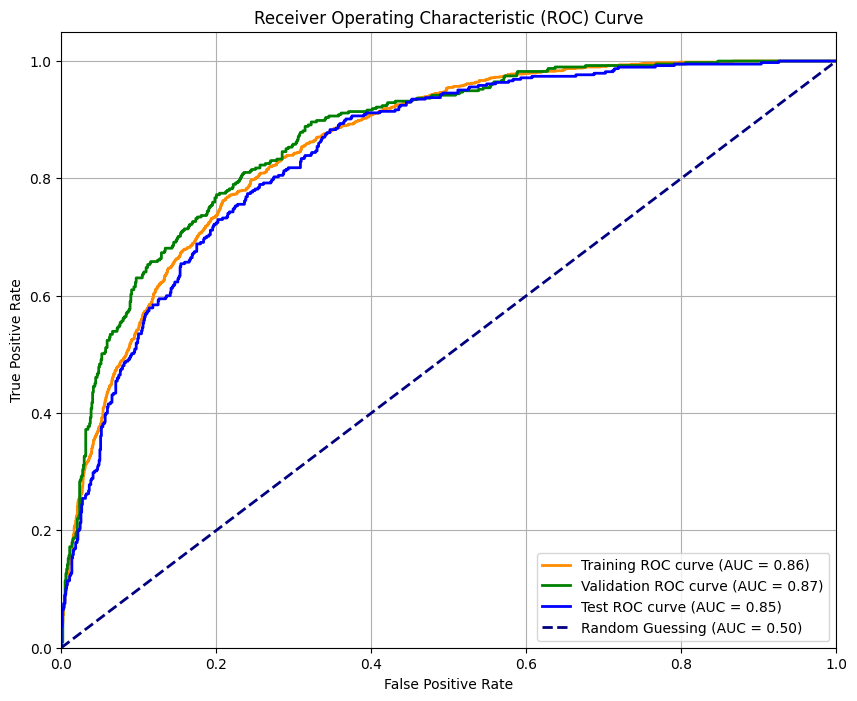

Training AUC: 0.8570
Validation AUC: 0.8698
Test AUC: 0.8458


In [687]:
# Calculate ROC curve and AUC for the training set
# Use the numerical Churn Value for y_true
fpr_train, tpr_train, thresholds_train = roc_curve(y_train.map({'Yes': 1, 'No': 0}), y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

# Calculate ROC curve and AUC for the validation set
# Use the numerical Churn Value for y_true
fpr_val, tpr_val, thresholds_val = roc_curve(y_val.map({'Yes': 1, 'No': 0}), y_val_proba)
roc_auc_val = auc(fpr_val, tpr_val)

# Calculate ROC curve and AUC for the test set
# Use the numerical Churn Value for y_true
fpr_test, tpr_test, thresholds_test = roc_curve(y_test.map({'Yes': 1, 'No': 0}), y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='Training ROC curve (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_val, tpr_val, color='green', lw=2, label='Validation ROC curve (AUC = %0.2f)' % roc_auc_val)
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label='Test ROC curve (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)') # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Training AUC: {roc_auc_train:.4f}")
print(f"Validation AUC: {roc_auc_val:.4f}")
print(f"Test AUC: {roc_auc_test:.4f}")

**Prompt 6:** Comment on the model performance. What did you observe in the results?

**Answer:** We see that accuracy increased between training and validation but decreased in the test set. For churn values, precision increased between training and validation but fell from validation to test. The same pattern followed for recall, f-1 score and AUC. The validation partition yielded the most accurate and beneficial results.

## Variable Selection

**Prompt 7:** Check for predictor significance. Are any predictors insignificant? Which ones?

In [688]:
# Convert boolean columns to integers (0s and 1s) for statsmodels
X_train_sm = X_train.astype(int)

# Convert y_train to numerical (0s and 1s) for statsmodels
y_train_sm = y_train.map({'Yes': 1, 'No': 0})

# Add a constant (intercept) to the features for statsmodels
X_train_sm = sm.add_constant(X_train_sm)

# Fit the logistic regression model using statsmodels
logit_model = sm.Logit(y_train_sm, X_train_sm)
result = logit_model.fit()

# Show the model summary, which includes p-values
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.397375
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            Churn Label   No. Observations:                 4225
Model:                          Logit   Df Residuals:                     4206
Method:                           MLE   Df Model:                           18
Date:                Thu, 16 Oct 2025   Pseudo R-squ.:                  0.3037
Time:                        00:18:16   Log-Likelihood:                -1678.9
converged:                       True   LL-Null:                       -2411.2
Covariance Type:            nonrobust   LLR p-value:                1.992e-300
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -1.7597      0.313     -5.624  

In [689]:
# Automate variable selection using Backward Elimination based on p-values

def backward_elimination(X, y, significance_level=0.05):
    """
    Performs backward elimination to select features based on p-values.

    Args:
        X (pd.DataFrame): DataFrame of predictor variables.
        y (pd.Series): Series of the target variable.
        significance_level (float): The alpha level for statistical significance.

    Returns:
        list: A list of the selected feature names.
    """
    features = X.columns.tolist()
    # Convert y to numerical for statsmodels compatibility
    y_numeric = y.map({'Yes': 1, 'No': 0})

    while (len(features) > 0):
        # Create a copy and convert boolean columns to integers for statsmodels compatibility
        X_be = X[features].copy()
        for col in X_be.columns:
            if X_be[col].dtype == bool:
                X_be[col] = X_be[col].astype(int)

        X_train_be = sm.add_constant(X_be)
        # Use the numerical target variable
        model_be = sm.OLS(y_numeric, X_train_be).fit()
        p_values = model_be.pvalues[1:] # Exclude constant's p-value
        max_p_value = max(p_values)
        if max_p_value > significance_level:
            redundant_feature = p_values.idxmax()
            features.remove(redundant_feature)
        else:
            break
    return features

# Perform backward elimination on the training data
selected_features = backward_elimination(X_train, y_train)

print("Selected features after backward elimination:", selected_features)

# You can now use these selected features to train a new model
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

# Display the shapes of the selected feature sets
print("\nShape of training data with selected features:", X_train_selected.shape)
print("Shape of validation data with selected features:", X_val_selected.shape)
print("Shape of test data with selected features:", X_test_selected.shape)

Selected features after backward elimination: ['Tenure Months', 'Monthly Charges', 'Contract_One year', 'Contract_Two year', 'Partner_Yes', 'Dependents_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_Yes', 'Online Backup_Yes', 'Tech Support_Yes', 'Paperless Billing_Yes', 'Electronic Check_Yes']

Shape of training data with selected features: (4225, 15)
Shape of validation data with selected features: (1409, 15)
Shape of test data with selected features: (1409, 15)


**Answer:** Based on the automate variable selection using Backward Elimination based on p-values there exist various insignificant predictors. These include Gender_Male, Senior Citizen_Yes, and Device Protection_Yes.

**Prompt 8:** Re-train the model using just the statistically significant predictors.

In [690]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Rerun the Logistic Regression model with the selected subset of predictors and appropriate metrics

# Initialize the Logistic Regression model
model_selected = LogisticRegression(random_state=42)

# Fit the model to the training data with selected features
# Use the numerical 'Churn Value' column as the target
model_selected.fit(X_train_selected, y_train.map({'Yes': 1, 'No': 0}))

# Make predictions on the training, validation, and test sets with selected features
y_train_pred_selected = model_selected.predict(X_train_selected)
y_val_pred_selected = model_selected.predict(X_val_selected)
y_test_pred_selected = model_selected.predict(X_test_selected)

# Get predicted probabilities for AUC calculation
y_train_proba_selected = model_selected.predict_proba(X_train_selected)[:, 1]
y_val_proba_selected = model_selected.predict_proba(X_val_selected)[:, 1]
y_test_proba_selected = model_selected.predict_proba(X_test_selected)[:, 1]

# Evaluate the new model on the training, validation, and test sets using classification metrics
train_accuracy_selected = accuracy_score(y_train.map({'Yes': 1, 'No': 0}), y_train_pred_selected)
val_accuracy_selected = accuracy_score(y_val.map({'Yes': 1, 'No': 0}), y_val_pred_selected)
test_accuracy_selected = accuracy_score(y_test.map({'Yes': 1, 'No': 0}), y_test_pred_selected)

train_report_selected = classification_report(y_train.map({'Yes': 1, 'No': 0}), y_train_pred_selected)
val_report_selected = classification_report(y_val.map({'Yes': 1, 'No': 0}), y_val_pred_selected)
test_report_selected = classification_report(y_test.map({'Yes': 1, 'No': 0}), y_test_pred_selected)

train_auc_selected = roc_auc_score(y_train.map({'Yes': 1, 'No': 0}), y_train_proba_selected)
val_auc_selected = roc_auc_score(y_val.map({'Yes': 1, 'No': 0}), y_val_proba_selected)
test_auc_selected = roc_auc_score(y_test.map({'Yes': 1, 'No': 0}), y_test_proba_selected)

# Print the performance metrics for the new model
print("Model Performance with Selected Features:")
print("\nTraining Set:")
print(f"  Accuracy: {train_accuracy_selected:.4f}")
print(train_report_selected)
print(f"  AUC: {train_auc_selected:.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {val_accuracy_selected:.4f}")
print(val_report_selected)
print(f"  AUC: {val_auc_selected:.4f}")

print("\nTest Set:")
print(f"  Accuracy: {test_accuracy_selected:.4f}")
print(test_report_selected)
print(f"  AUC: {test_auc_selected:.4f}")

# Print the model coefficients and intercept for the new model
print("\nModel Coefficients with Selected Features:")
for feature, coef in zip(X_train_selected.columns, model_selected.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

print(f"\nIntercept: {model_selected.intercept_[0]:.4f}")

Model Performance with Selected Features:

Training Set:
  Accuracy: 0.8090
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      3136
           1       0.66      0.54      0.59      1089

    accuracy                           0.81      4225
   macro avg       0.75      0.72      0.73      4225
weighted avg       0.80      0.81      0.80      4225

  AUC: 0.8569

Validation Set:
  Accuracy: 0.8247
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1014
           1       0.72      0.62      0.66       395

    accuracy                           0.82      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.82      0.82      0.82      1409

  AUC: 0.8699

Test Set:
  Accuracy: 0.8006
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1024
           1       0.66      0.55      0.60       385

    accuracy

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Prompt 9:** Check model performance again by partition with total accuracy, precision, recall, F1 score, and AUC.

Confusion Matrix - Training Set:
[[2829  307]
 [ 500  589]]

Confusion Matrix - Validation Set:
[[918  96]
 [151 244]]

Confusion Matrix - Test Set:
[[915 109]
 [172 213]]


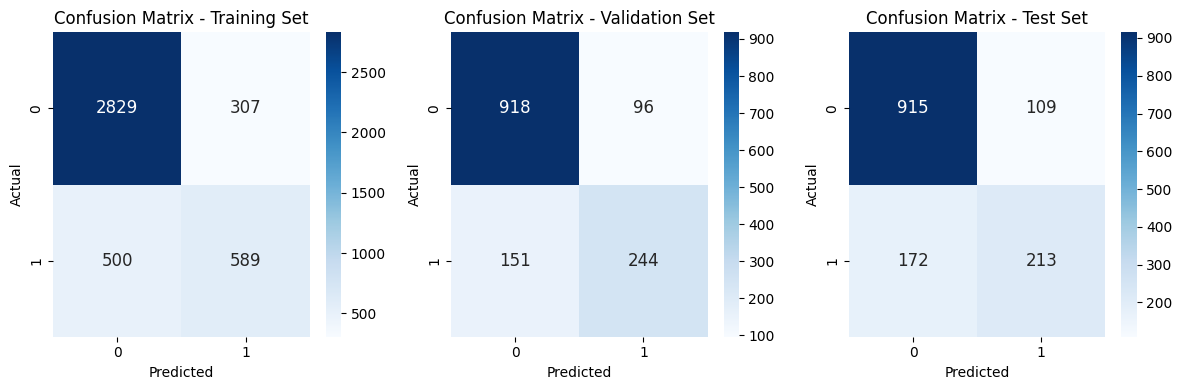

In [691]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix for the training set utilziing new model results for cm_train
cm_train = confusion_matrix(y_train.map({'Yes': 1, 'No': 0}), y_train_pred_selected)
print("Confusion Matrix - Training Set:")
print(cm_train)

# Calculate confusion matrix for the validation set utilziing new model results for cm_val
cm_val = confusion_matrix(y_val.map({'Yes': 1, 'No': 0}), y_val_pred_selected)
print("\nConfusion Matrix - Validation Set:")
print(cm_val)

# Calculate confusion matrix for the validation set utilziing new model results for cm_test
cm_test = confusion_matrix(y_test.map({'Yes': 1, 'No': 0}), y_test_pred_selected)
print("\nConfusion Matrix - Test Set:")
print(cm_test)

# Optional: Visualize Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 12})
axes[0].set_title('Confusion Matrix - Training Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 12})
axes[1].set_title('Confusion Matrix - Validation Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[2], annot_kws={"size": 12})
axes[2].set_title('Confusion Matrix - Test Set')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

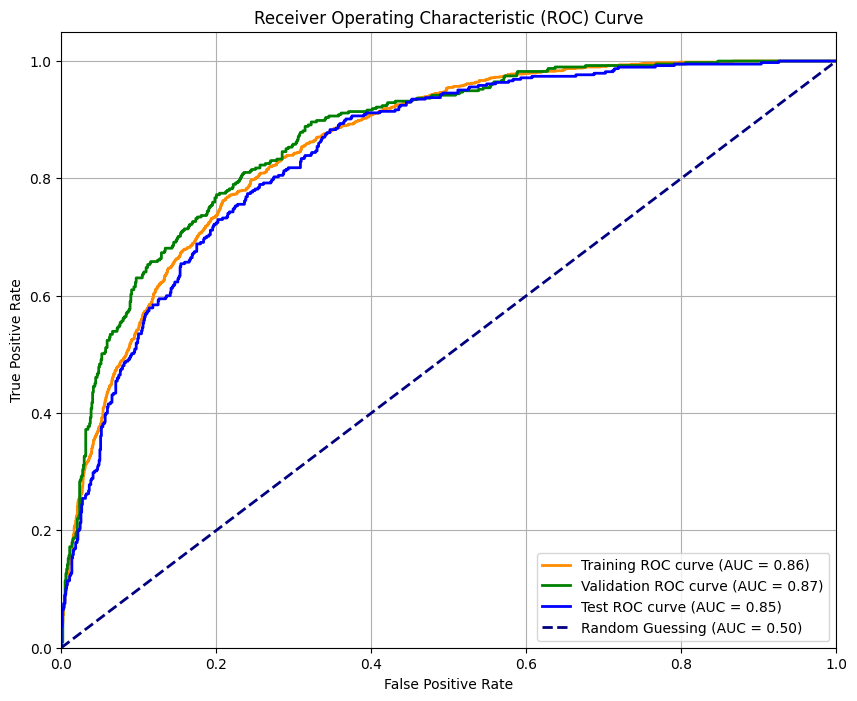

Training AUC: 0.8570
Validation AUC: 0.8698
Test AUC: 0.8458


In [692]:
# Calculate ROC curve and AUC for the training set
fpr_train, tpr_train, thresholds_train = roc_curve(y_train.map({'Yes': 1, 'No': 0}), y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

# Calculate ROC curve and AUC for the validation set
fpr_val, tpr_val, thresholds_val = roc_curve(y_val.map({'Yes': 1, 'No': 0}), y_val_proba)
roc_auc_val = auc(fpr_val, tpr_val)

# Calculate ROC curve and AUC for the test set
fpr_test, tpr_test, thresholds_test = roc_curve(y_test.map({'Yes': 1, 'No': 0}), y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='Training ROC curve (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_val, tpr_val, color='green', lw=2, label='Validation ROC curve (AUC = %0.2f)' % roc_auc_val)
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label='Test ROC curve (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)') # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Training AUC: {roc_auc_train:.4f}")
print(f"Validation AUC: {roc_auc_val:.4f}")
print(f"Test AUC: {roc_auc_test:.4f}")

**Prompt 10:** How did performance change? Which model is better?

**Answer:** Unfortunately, there were no improvements. While many metric values are similar, the initial model was still better than the current one.

##Interaction Terms

**Prompt 11:** Re-train the model with the addition of an interaction term.  What variables did you combine and why?  Is the new interaction term statistically significant?

In [693]:
# Create the interaction term between Monthly Charges and Dependents_Yes
X_train_interact = X_train_encoded.copy() # Use encoded data
X_val_interact = X_val_encoded.copy() # Use encoded data
X_test_interact = X_test_encoded.copy() # Use encoded data

# Check if 'Dependents_Yes_True' and 'Monthly Charges' columns exist before creating interaction
if 'Dependents_Yes_True' in X_train_interact.columns and 'Monthly Charges' in X_train_interact.columns:
    X_train_interact['Monthly_Charges_Dependents_Interaction'] = X_train_interact['Monthly Charges'] * X_train_interact['Dependents_Yes_True']
    X_val_interact['Monthly_Charges_Dependents_Interaction'] = X_val_interact['Monthly Charges'] * X_val_interact['Dependents_Yes_True']
    X_test_interact['Monthly_Charges_Dependents_Interaction'] = X_test_interact['Monthly Charges'] * X_test_interact['Dependents_Yes_True']
    print("Monthly_Charges_Dependents_Interaction term created.")
else:
    print("Warning: 'Dependents_Yes_True' or 'Monthly Charges' not found in features. Interaction term not created.")


# Initialize and train the Logistic Regression model with the interaction term
logistic_model_interact = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter to address potential convergence issues
logistic_model_interact.fit(X_train_interact, y_train)

print("Logistic Regression model with Monthly Charges and Dependents_Yes interaction term trained successfully.")

# Make predictions with the new model
y_train_pred_interact = logistic_model_interact.predict(X_train_interact)
y_val_pred_interact = logistic_model_interact.predict(X_val_interact)
y_test_pred_interact = logistic_model_interact.predict(X_test_interact)

# Get predicted probabilities with the new model
y_train_proba_interact = logistic_model_interact.predict_proba(X_train_interact)[:, 1]
y_val_proba_interact = logistic_model_interact.predict_proba(X_val_interact)[:, 1]
y_test_proba_interact = logistic_model_interact.predict_proba(X_test_interact)[:, 1]

print("Predictions with interaction term made successfully.")

Monthly_Charges_Dependents_Interaction term created.
Logistic Regression model with Monthly Charges and Dependents_Yes interaction term trained successfully.
Predictions with interaction term made successfully.


Check to see if the new interaction term is statistically significant.

In [694]:
# Convert boolean columns to integers (0s and 1s) for statsmodels, if any
X_train_interact_sm = X_train_interact.copy()
for col in X_train_interact_sm.columns:
    if X_train_interact_sm[col].dtype == bool:
        X_train_interact_sm[col] = X_train_interact_sm[col].astype(int)

# Ensure the target variable is numerical (0s and 1s)
y_train_sm = y_train.map({'Yes': 1, 'No': 0})

# Add a constant (intercept) to the features for statsmodels
X_train_interact_sm = sm.add_constant(X_train_interact_sm)

# Fit the logistic regression model using statsmodels
logit_model_interact = sm.Logit(y_train_sm, X_train_interact_sm)
result_interact = logit_model_interact.fit()

# Show the model summary, which includes p-values
print(result_interact.summary())

Optimization terminated successfully.
         Current function value: 0.396086
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            Churn Label   No. Observations:                 4225
Model:                          Logit   Df Residuals:                     4205
Method:                           MLE   Df Model:                           19
Date:                Thu, 16 Oct 2025   Pseudo R-squ.:                  0.3060
Time:                        00:18:20   Log-Likelihood:                -1673.5
converged:                       True   LL-Null:                       -2411.2
Covariance Type:            nonrobust   LLR p-value:                8.346e-302
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -1.8769   

**Answer:** I wanted to examine the combination of how monthly charges and dependents would affect the model. Yes, this term is significant!

**Prompt 12:** Check model performance again by partition with total accuracy, precision, recall, F1 score, and AUC.

Confusion Matrix - Training Set (with Interaction Term):
[[2819  317]
 [ 497  592]]

Confusion Matrix - Validation Set (with Interaction Term):
[[917  97]
 [149 246]]

Confusion Matrix - Test Set (with Interaction Term):
[[916 108]
 [172 213]]


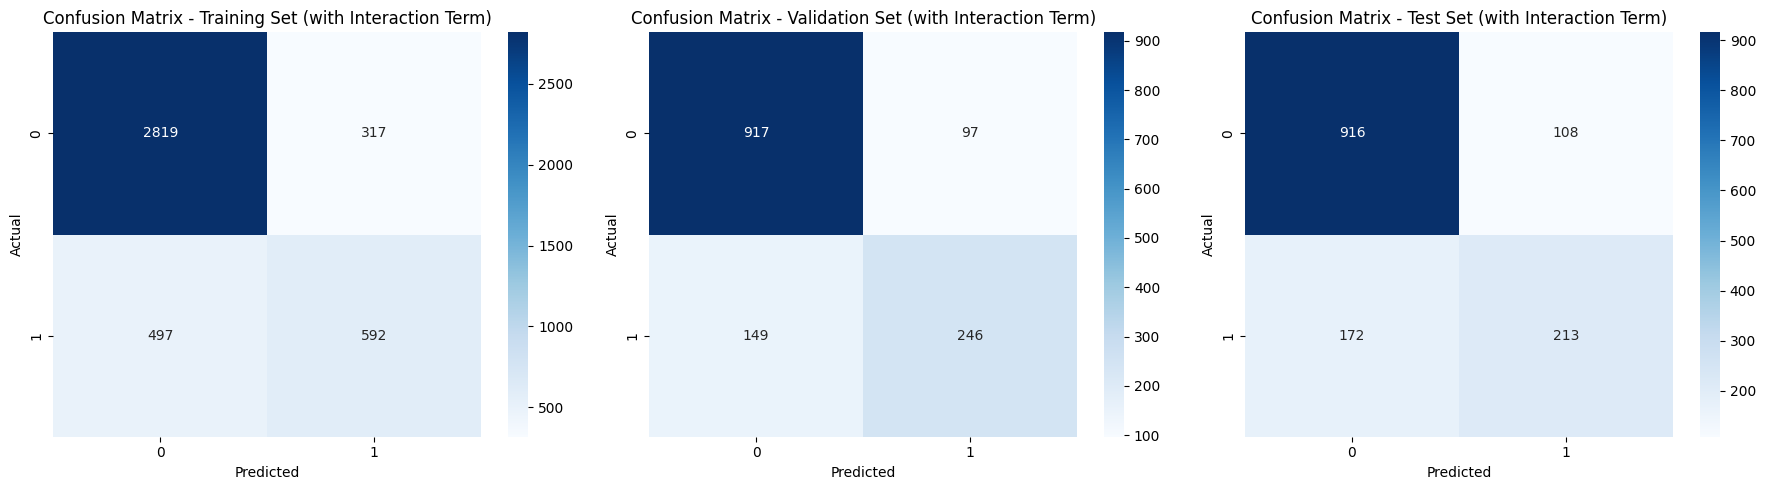

In [695]:
# Calculate confusion matrix for the training set with interaction term
cm_train_interact = confusion_matrix(y_train, y_train_pred_interact)
print("Confusion Matrix - Training Set (with Interaction Term):")
print(cm_train_interact)

# Calculate confusion matrix for the validation set with interaction term
cm_val_interact = confusion_matrix(y_val, y_val_pred_interact)
print("\nConfusion Matrix - Validation Set (with Interaction Term):")
print(cm_val_interact)

# Calculate confusion matrix for the test set with interaction term
cm_test_interact = confusion_matrix(y_test, y_test_pred_interact)
print("\nConfusion Matrix - Test Set (with Interaction Term):")
print(cm_test_interact)

# Optional: Visualize Confusion Matrices with Interaction Term
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_train_interact, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Training Set (with Interaction Term)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_val_interact, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Validation Set (with Interaction Term)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(cm_test_interact, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Confusion Matrix - Test Set (with Interaction Term)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [696]:
from sklearn.metrics import classification_report

# Show classification report for the training set based on the model with the interact term
print("Classification Report - Training Set (with Interaction Term):")
print(classification_report(y_train, y_train_pred_interact))

# Show classification report for the valdiation set based on the model with the interact term
print("\nClassification Report - Validation Set (with Interaction Term):")
print(classification_report(y_val, y_val_pred_interact))

# Show classification report for the test set based on the model with the interact term
print("\nClassification Report - Test Set (with Interaction Term):")
print(classification_report(y_test, y_test_pred_interact))

Classification Report - Training Set (with Interaction Term):
              precision    recall  f1-score   support

          No       0.85      0.90      0.87      3136
         Yes       0.65      0.54      0.59      1089

    accuracy                           0.81      4225
   macro avg       0.75      0.72      0.73      4225
weighted avg       0.80      0.81      0.80      4225


Classification Report - Validation Set (with Interaction Term):
              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1014
         Yes       0.72      0.62      0.67       395

    accuracy                           0.83      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.82      0.83      0.82      1409


Classification Report - Test Set (with Interaction Term):
              precision    recall  f1-score   support

          No       0.84      0.89      0.87      1024
         Yes       0.66      0.55      0.60       3

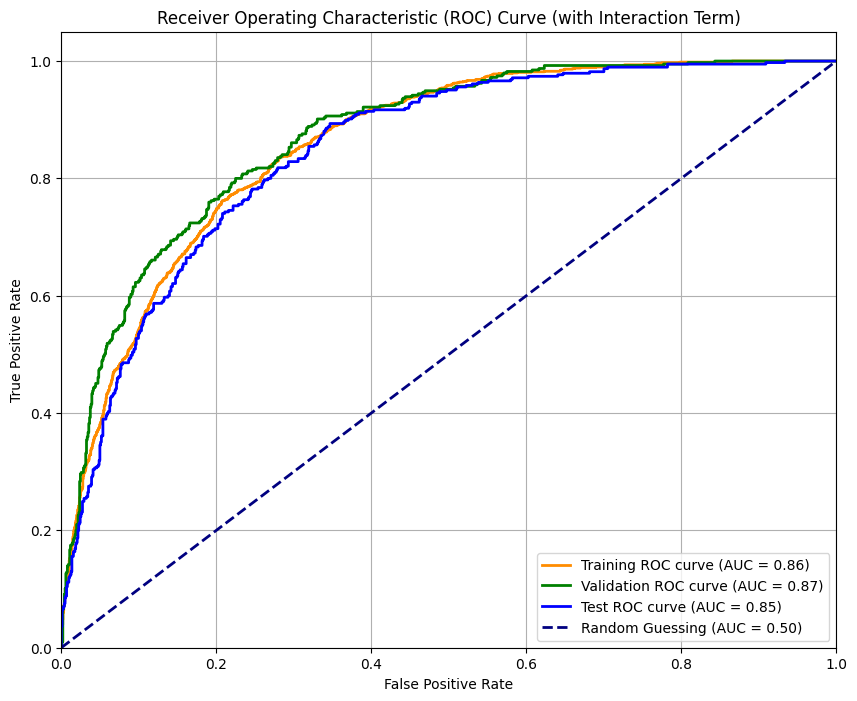

Training AUC (with Interaction Term): 0.8582
Validation AUC (with Interaction Term): 0.8711
Test AUC (with Interaction Term): 0.8475


In [697]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC for the training set with interaction term
fpr_train_interact, tpr_train_interact, thresholds_train_interact = roc_curve(y_train.map({'Yes': 1, 'No': 0}), y_train_proba_interact)
roc_auc_train_interact = auc(fpr_train_interact, tpr_train_interact)

# Calculate ROC curve and AUC for the validation set with interaction term
fpr_val_interact, tpr_val_interact, thresholds_val_interact = roc_curve(y_val.map({'Yes': 1, 'No': 0}), y_val_proba_interact)
roc_auc_val_interact = auc(fpr_val_interact, tpr_val_interact)

# Calculate ROC curve and AUC for the test set with interaction term
fpr_test_interact, tpr_test_interact, thresholds_test_interact = roc_curve(y_test.map({'Yes': 1, 'No': 0}), y_test_proba_interact)
roc_auc_test_interact = auc(fpr_test_interact, tpr_test_interact)

# Plot ROC curves with interaction term
plt.figure(figsize=(10, 8))
plt.plot(fpr_train_interact, tpr_train_interact, color='darkorange', lw=2, label='Training ROC curve (AUC = %0.2f)' % roc_auc_train_interact)
plt.plot(fpr_val_interact, tpr_val_interact, color='green', lw=2, label='Validation ROC curve (AUC = %0.2f)' % roc_auc_val_interact)
plt.plot(fpr_test_interact, tpr_test_interact, color='blue', lw=2, label='Test ROC curve (AUC = %0.2f)' % roc_auc_test_interact)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)') # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (with Interaction Term)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Training AUC (with Interaction Term): {roc_auc_train_interact:.4f}")
print(f"Validation AUC (with Interaction Term): {roc_auc_val_interact:.4f}")
print(f"Test AUC (with Interaction Term): {roc_auc_test_interact:.4f}")

**Prompt 13:** Did adding the interaction term improve your model?  Why or why not?

**Answer:** Yes, it did. There was a slight improvement because of the positive correlation between the two variables.

**Prompt 14:** Make a final choice of which of the three models is best?  Justify your response.

**Answer:** While there is mininal overall improvement, the model with the interaction term was a little better due to the AUC metric on the test set. This was a strong measure of model performance, and suggests that the interaction term between the Monthly Charges and Dependants_Yes variable yielded better results than the other two models.